In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### PROBLEM STATEMENT :
Build an Enterprise Retail Intelligence Platform that forecasts SKU-level demand across stores using historical sales, seasonality, promotions, and regional factors to improve forecast accuracy.
Generate AI-driven inventory recommendations and business insights to optimize replenishment, reduce stockouts and excess inventory, and support smarter retail decision-making.


### IMPORTING ESSENTIAL LIBARIES


In [3]:
%pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 889.7 kB/s eta 0:00:00


In [5]:
%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.4/303.4 MB 1.2 MB/s eta 0:00:00


In [6]:
%pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 75.0 MB/s eta 0:00:00


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, gc, os
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              accuracy_score, classification_report)

import xgboost as xgb
import lightgbm as lgb

from catboost import CatBoostRegressor

import joblib

print("All libraries imported successfully!")
print(f"pandas {pd.__version__}  |  numpy {np.__version__}")

All libraries imported successfully!
pandas 2.2.2  |  numpy 2.0.2


## PHASE 1: DATA UNDERSTANDING


### LOADING RAW FILES


In [8]:
# ── File Paths ────────────────────────────────────────────────────────────
SALES_PATH    = '/content/drive/MyDrive/datasets /final project/Copy of sales_train_validation.csv'
CALENDAR_PATH = '/content/drive/MyDrive/datasets /final project/Copy of calendar.csv'
PRICES_PATH   = '/content/drive/MyDrive/datasets /final project/Copy of sell_prices.csv'
# ──────────────────────────────────────────────────────────────────────────

# Compressed dtypes save ~60% RAM on sales file
cat_dtypes = {c: 'category'
              for c in ['id','item_id','dept_id','cat_id','store_id','state_id']}

sales_df    = pd.read_csv(SALES_PATH, dtype=cat_dtypes)
calendar_df = pd.read_csv(CALENDAR_PATH)
prices_df   = pd.read_csv(PRICES_PATH,
                           dtype={'store_id':'category', 'item_id':'category',
                                  'wm_yr_wk':'int32', 'sell_price':'float32'})

print(f"sales_df    : {sales_df.shape[0]:>6,} rows × {sales_df.shape[1]:>5} cols")
print(f"calendar_df : {calendar_df.shape[0]:>6,} rows × {calendar_df.shape[1]:>5} cols")
print(f"prices_df   : {prices_df.shape[0]:>6,} rows × {prices_df.shape[1]:>5} cols")

sales_df    : 30,490 rows ×  1919 cols
calendar_df :  1,969 rows ×    14 cols
prices_df   : 6,841,121 rows ×     4 cols


#### Product hierarchy analysis


In [9]:
id_cols  = ['id','item_id','dept_id','cat_id','store_id','state_id']
day_cols = [c for c in sales_df.columns if c.startswith('d_')]

print("=" * 50)
print("  PRODUCT HIERARCHY")
print("=" * 50)
print(f"  Total SKUs (item × store): {len(sales_df):>6,}")
print(f"  Unique items             : {sales_df['item_id'].nunique():>6,}")
print(f"  Departments              : {sales_df['dept_id'].nunique():>6,}")
print(f"  Categories               : {sales_df['cat_id'].nunique():>6,}")
print(f"  Stores                   : {sales_df['store_id'].nunique():>6,}")
print(f"  States                   : {sales_df['state_id'].nunique():>6,}")
print(f"  Daily columns            : {len(day_cols):>6,}  (d_1 → d_{len(day_cols)})")
print()
print("Categories :", sales_df['cat_id'].unique().tolist())
print("Departments:", sales_df['dept_id'].unique().tolist())
print()
print(sales_df[id_cols].head(8).to_string(index=False))

  PRODUCT HIERARCHY
  Total SKUs (item × store): 30,490
  Unique items             :  3,049
  Departments              :      7
  Categories               :      3
  Stores                   :     10
  States                   :      3
  Daily columns            :  1,913  (d_1 → d_1913)

Categories : ['HOBBIES', 'HOUSEHOLD', 'FOODS']
Departments: ['HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2', 'FOODS_1', 'FOODS_2', 'FOODS_3']

                           id       item_id   dept_id  cat_id store_id state_id
HOBBIES_1_001_CA_1_validation HOBBIES_1_001 HOBBIES_1 HOBBIES     CA_1       CA
HOBBIES_1_002_CA_1_validation HOBBIES_1_002 HOBBIES_1 HOBBIES     CA_1       CA
HOBBIES_1_003_CA_1_validation HOBBIES_1_003 HOBBIES_1 HOBBIES     CA_1       CA
HOBBIES_1_004_CA_1_validation HOBBIES_1_004 HOBBIES_1 HOBBIES     CA_1       CA
HOBBIES_1_005_CA_1_validation HOBBIES_1_005 HOBBIES_1 HOBBIES     CA_1       CA
HOBBIES_1_006_CA_1_validation HOBBIES_1_006 HOBBIES_1 HOBBIES     CA_1       CA


#### Store hierarchy analysis

In [10]:
store_state = (sales_df[['store_id','state_id']]
               .drop_duplicates()
               .sort_values('store_id')
               .reset_index(drop=True))
print("Store → State mapping:")
print(store_state.to_string(index=False))

items_per_store = sales_df.groupby('store_id')['item_id'].nunique().reset_index()
items_per_store.columns = ['store_id','unique_items']
print()
print(items_per_store.to_string(index=False))

Store → State mapping:
store_id state_id
    CA_1       CA
    CA_2       CA
    CA_3       CA
    CA_4       CA
    TX_1       TX
    TX_2       TX
    TX_3       TX
    WI_1       WI
    WI_2       WI
    WI_3       WI

store_id  unique_items
    CA_1          3049
    CA_2          3049
    CA_3          3049
    CA_4          3049
    TX_1          3049
    TX_2          3049
    TX_3          3049
    WI_1          3049
    WI_2          3049
    WI_3          3049


#### Calendar analysis

In [11]:
print("Calendar date range:", calendar_df['date'].min(), "→", calendar_df['date'].max())
print()
print(calendar_df[['date','wm_yr_wk','weekday','wday','month','year',
                    'event_name_1','event_type_1','snap_CA','snap_TX','snap_WI']].head(8).to_string(index=False))
print()
print("Event type distribution:")
print(calendar_df['event_type_1'].value_counts(dropna=False).to_string())
print()
print("SNAP days per state:")
print(f"  CA: {calendar_df['snap_CA'].sum()}  TX: {calendar_df['snap_TX'].sum()}  WI: {calendar_df['snap_WI'].sum()}")

Calendar date range: 2011-01-29 → 2016-06-19

      date  wm_yr_wk   weekday  wday  month  year event_name_1 event_type_1  snap_CA  snap_TX  snap_WI
2011-01-29     11101  Saturday     1      1  2011          NaN          NaN        0        0        0
2011-01-30     11101    Sunday     2      1  2011          NaN          NaN        0        0        0
2011-01-31     11101    Monday     3      1  2011          NaN          NaN        0        0        0
2011-02-01     11101   Tuesday     4      2  2011          NaN          NaN        1        1        0
2011-02-02     11101 Wednesday     5      2  2011          NaN          NaN        1        0        1
2011-02-03     11101  Thursday     6      2  2011          NaN          NaN        1        1        1
2011-02-04     11101    Friday     7      2  2011          NaN          NaN        1        0        0
2011-02-05     11102  Saturday     1      2  2011          NaN          NaN        1        1        1

Event type distribution:
e

#### Merge the 3 Files


In [12]:
# ── Use last 90 days only ────────────────────────────────────────────────
USE_DAYS = day_cols[-90:]          # d_1824 (2016-01-26) → d_1913 (2016-04-24)
# ─────────────────────────────────────────────────────────────────────────

print(f"Modelling window: {USE_DAYS[0]} → {USE_DAYS[-1]}  ({len(USE_DAYS)} days)")
print(f"Long-format rows : {len(sales_df) * len(USE_DAYS):,}")

# Cast day columns to int16 before melt
for d in USE_DAYS:
    sales_df[d] = sales_df[d].astype(np.int16)

sales_long = (sales_df[id_cols + USE_DAYS]
              .melt(id_vars=id_cols, value_vars=USE_DAYS,
                    var_name='d', value_name='sales'))
sales_long['sales'] = sales_long['sales'].astype(np.float32)

# Merge calendar
CAL_KEEP = ['d','date','wm_yr_wk','weekday','wday','month','year',
            'event_name_1','event_type_1','event_name_2','event_type_2',
            'snap_CA','snap_TX','snap_WI']
df = sales_long.merge(calendar_df[CAL_KEEP], on='d', how='left')
del sales_long; gc.collect()

# Merge prices
df['wm_yr_wk'] = df['wm_yr_wk'].astype('int32')
df = df.merge(prices_df[['store_id','item_id','wm_yr_wk','sell_price']],
              on=['store_id','item_id','wm_yr_wk'], how='left')
del prices_df; gc.collect()

df['date'] = pd.to_datetime(df['date'])
print(f"\nMerged DataFrame: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(df[['id','date','sales','sell_price','event_type_1']].head(6).to_string(index=False))

Modelling window: d_1824 → d_1913  (90 days)
Long-format rows : 2,744,100

Merged DataFrame: 2,744,100 rows × 22 cols
                           id       date  sales  sell_price event_type_1
HOBBIES_1_001_CA_1_validation 2016-01-26    1.0        8.26          NaN
HOBBIES_1_002_CA_1_validation 2016-01-26    0.0        3.97          NaN
HOBBIES_1_003_CA_1_validation 2016-01-26    0.0        2.97          NaN
HOBBIES_1_004_CA_1_validation 2016-01-26    1.0        4.64          NaN
HOBBIES_1_005_CA_1_validation 2016-01-26    0.0        2.88          NaN
HOBBIES_1_006_CA_1_validation 2016-01-26    0.0        0.96          NaN


In [13]:
os.makedirs('artifacts', exist_ok=True)
df.to_csv('artifacts/merged_data.csv', index=False)
print('\nMerged DataFrame saved to artifacts/merged_data.csv')


Merged DataFrame saved to artifacts/merged_data.csv


## Phase 2 :Data Cleaning


#### CHECKING AND FILLING THE MISSING VALUES

In [14]:
## CHECKING MISSSING VLAUES
missing = df.isnull().sum()
missing_pct = missing / len(df) * 100
report = (pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
           .query('`Missing Count` > 0')
           .sort_values('Missing %', ascending=False))
print(report.to_string())

              Missing Count   Missing %
event_name_2        2744100  100.000000
event_type_2        2744100  100.000000
event_name_1        2500180   91.111111
event_type_1        2500180   91.111111
sell_price              156    0.005685


In [15]:
# ── Fill missing values ───────────────────────────────────────────────────

# sell_price: fill with item median, then global median
df['sell_price'] = (df.groupby('item_id')['sell_price']
                      .transform(lambda x: x.fillna(x.median())))
df['sell_price'] = df['sell_price'].fillna(df['sell_price'].median()).astype(np.float32)

# Event columns → 'None'
for col in ['event_name_1','event_type_1','event_name_2','event_type_2']:
    if col in df.columns:
        df[col] = df[col].fillna('None')

# SNAP → 0
for col in ['snap_CA','snap_TX','snap_WI']:
    df[col] = df[col].fillna(0).astype(np.int8)

# Sales → 0
df['sales'] = df['sales'].fillna(0)

remaining = df.isnull().sum()[df.isnull().sum() > 0]
print("Missing after cleaning:", "None" if remaining.empty else remaining.to_string())

Missing after cleaning: None


#### OUTLIER TREATMENT


Sales distribution BEFORE:
count    2744100.000
mean           1.373
std            3.629
min            0.000
25%            0.000
50%            0.000
75%            1.000
max          248.000

Outliers (sales > 4 units): 201,384  (7.339% of rows)

Sales distribution AFTER:
count    2744100.000
mean           0.921
std            1.332
min            0.000
25%            0.000
50%            0.000
75%            1.000
max            4.000


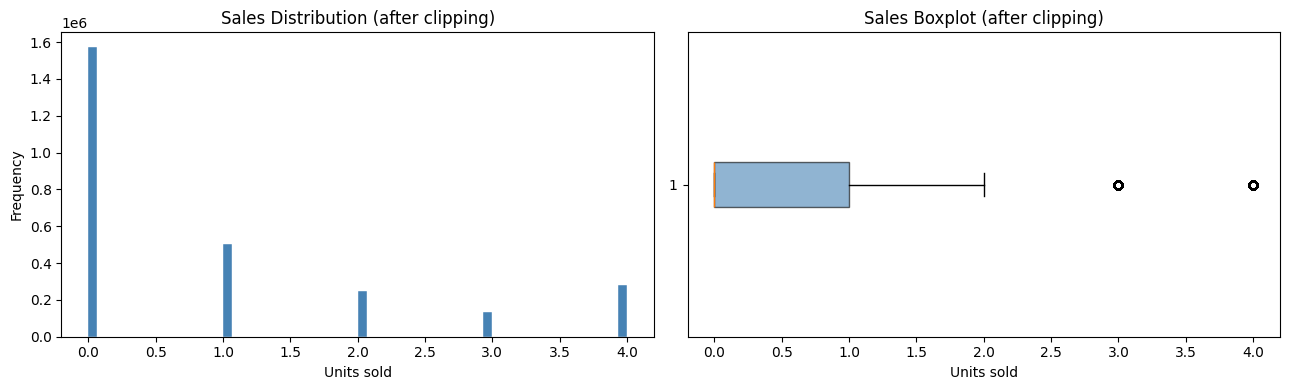

In [16]:
print("Sales distribution BEFORE:")
print(df['sales'].describe().round(3).to_string())

Q1 = df['sales'].quantile(0.25)
Q3 = df['sales'].quantile(0.75)
IQR = Q3 - Q1
upper_cap = Q3 + 3 * IQR

outliers_n = (df['sales'] > upper_cap).sum()
print(f"\nOutliers (sales > {upper_cap:.0f} units): {outliers_n:,}  "
      f"({outliers_n/len(df)*100:.3f}% of rows)")

df['sales'] = df['sales'].clip(lower=0, upper=upper_cap)

print("\nSales distribution AFTER:")
print(df['sales'].describe().round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['sales'].values, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Sales Distribution (after clipping)')
axes[0].set_xlabel('Units sold'); axes[0].set_ylabel('Frequency')
axes[1].boxplot(df['sales'].values, vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Sales Boxplot (after clipping)')
axes[1].set_xlabel('Units sold')
plt.tight_layout(); plt.show()

#### Data consistency checks

In [17]:
print("=" * 48)
print("  DATA CONSISTENCY CHECKS")
print("=" * 48)
print(f"  Negative sales         : {(df['sales'] < 0).sum():>6,}")
print(f"  Negative prices        : {(df['sell_price'] < 0).sum():>6,}")
print(f"  Duplicate id+day rows  : {df.duplicated(subset=['id','d']).sum():>6,}")
dates = pd.to_datetime(df['date'].unique())
missing_dates = set(pd.date_range(dates.min(), dates.max())) - set(dates)
print(f"  Missing calendar dates : {len(missing_dates):>6,}")
print()
print("  All checks passed ✓")

  DATA CONSISTENCY CHECKS
  Negative sales         :      0
  Negative prices        :      0
  Duplicate id+day rows  :      0
  Missing calendar dates :      0

  All checks passed ✓


## PHASE 3: EDA

#### Product-level analysis

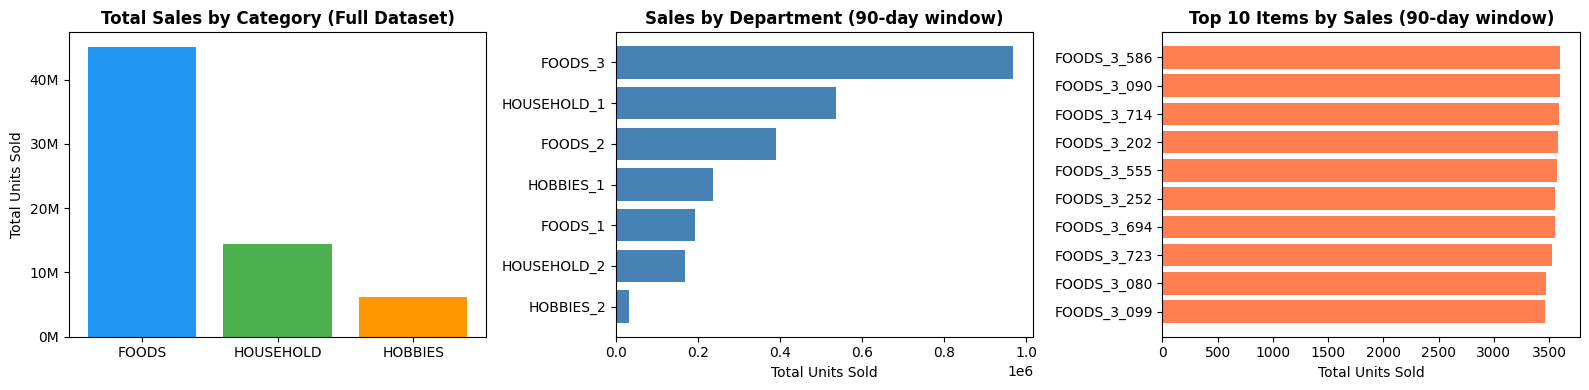

Full dataset category totals (units):
  FOODS       :   45,089,939
  HOUSEHOLD   :   14,480,670
  HOBBIES     :    6,124,800


In [18]:
# Total sales by category (all columns in original wide sales_df)
cat_totals = {'FOODS': 45089939, 'HOUSEHOLD': 14480670, 'HOBBIES': 6124800}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Category bar
ax = axes[0]
ax.bar(cat_totals.keys(), cat_totals.values(), color=['#2196F3','#4CAF50','#FF9800'])
ax.set_title('Total Sales by Category (Full Dataset)', fontweight='bold')
ax.set_ylabel('Total Units Sold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.0f}M'))

# Department breakdown (90-day window)
dept_sales = df.groupby('dept_id')['sales'].sum().sort_values(ascending=False)
ax = axes[1]
ax.barh(dept_sales.index, dept_sales.values, color='steelblue')
ax.set_title('Sales by Department (90-day window)', fontweight='bold')
ax.set_xlabel('Total Units Sold')
ax.invert_yaxis()

# Top 10 items
top_items = df.groupby('item_id')['sales'].sum().sort_values(ascending=False).head(10)
ax = axes[2]
ax.barh(top_items.index, top_items.values, color='coral')
ax.set_title('Top 10 Items by Sales (90-day window)', fontweight='bold')
ax.set_xlabel('Total Units Sold')
ax.invert_yaxis()

plt.tight_layout(); plt.show()

print("Full dataset category totals (units):")
for k,v in cat_totals.items():
    print(f"  {k:<12}: {v:>12,}")

### Store-level analysis

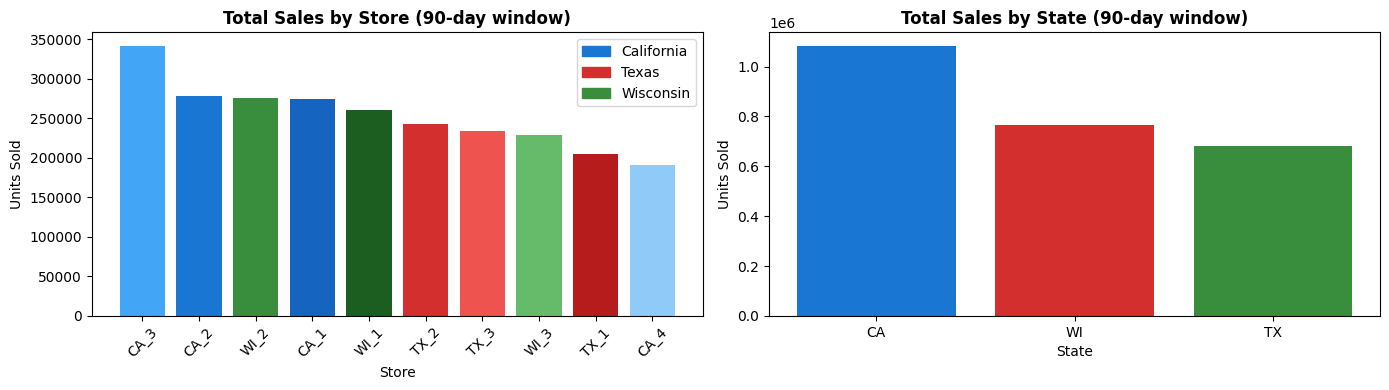

In [19]:
store_sales = df.groupby('store_id')['sales'].sum().sort_values(ascending=False)
state_sales = df.groupby('state_id')['sales'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = {'CA_1':'#1565C0','CA_2':'#1976D2','CA_3':'#42A5F5','CA_4':'#90CAF9',
          'TX_1':'#B71C1C','TX_2':'#D32F2F','TX_3':'#EF5350',
          'WI_1':'#1B5E20','WI_2':'#388E3C','WI_3':'#66BB6A'}
bar_colors = [colors.get(s,'grey') for s in store_sales.index]

axes[0].bar(store_sales.index, store_sales.values, color=bar_colors)
axes[0].set_title('Total Sales by Store (90-day window)', fontweight='bold')
axes[0].set_xlabel('Store')
axes[0].set_ylabel('Units Sold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(handles=[
    plt.Rectangle((0,0),1,1, color='#1976D2', label='California'),
    plt.Rectangle((0,0),1,1, color='#D32F2F', label='Texas'),
    plt.Rectangle((0,0),1,1, color='#388E3C', label='Wisconsin')
], loc='upper right')

axes[1].bar(state_sales.index, state_sales.values, color=['#1976D2','#D32F2F','#388E3C'])
axes[1].set_title('Total Sales by State (90-day window)', fontweight='bold')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Units Sold')

plt.tight_layout(); plt.show()

### Seasonal demand analysis

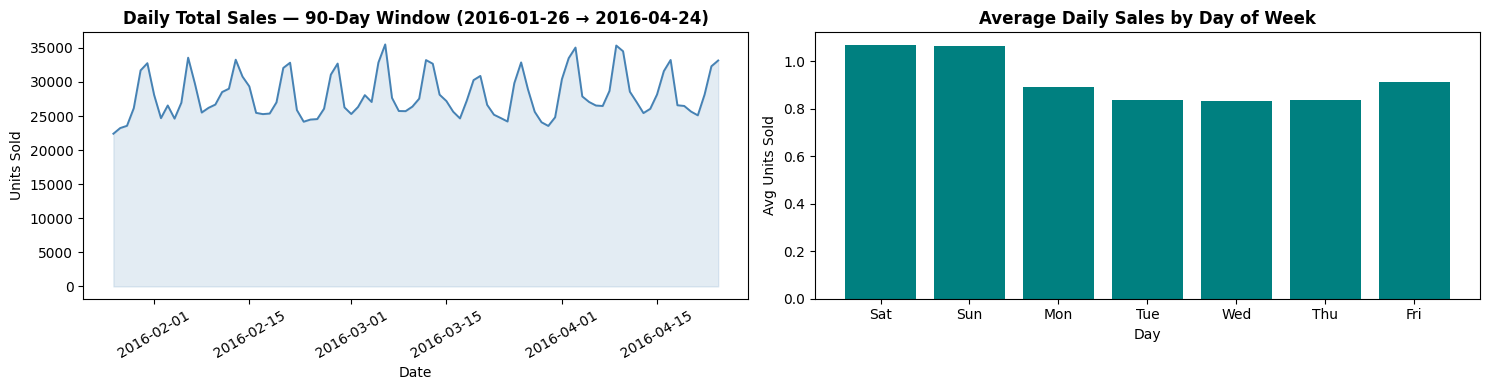

In [20]:
# Daily trend (90-day window)
daily = df.groupby('date')['sales'].sum().reset_index()

# Day-of-week pattern
dow_avg = df.groupby('wday')['sales'].mean().reset_index()
dow_map = {1:'Sat',2:'Sun',3:'Mon',4:'Tue',5:'Wed',6:'Thu',7:'Fri'}
dow_avg['day_name'] = dow_avg['wday'].map(dow_map)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(daily['date'], daily['sales'], color='steelblue', linewidth=1.4)
axes[0].fill_between(daily['date'], daily['sales'], alpha=0.15, color='steelblue')
axes[0].set_title('Daily Total Sales — 90-Day Window (2016-01-26 → 2016-04-24)', fontweight='bold')
axes[0].set_xlabel('Date'); axes[0].set_ylabel('Units Sold')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(dow_avg['day_name'], dow_avg['sales'], color='teal')
axes[1].set_title('Average Daily Sales by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day'); axes[1].set_ylabel('Avg Units Sold')

plt.tight_layout(); plt.show()

### Regional demand analysis

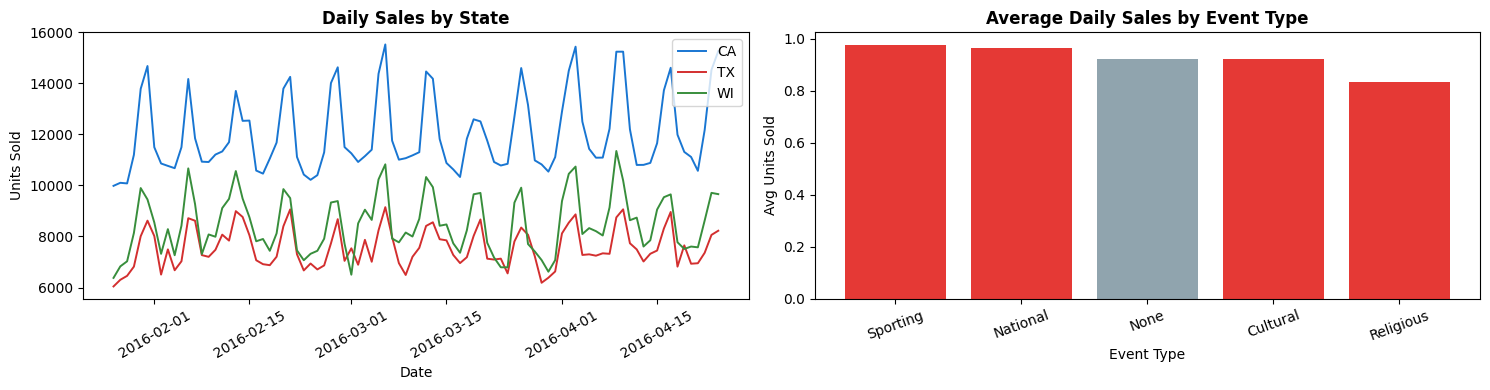

Average sales on event vs non-event days:
event_type_1
Sporting     0.975107
National     0.962545
None         0.923178
Cultural     0.922259
Religious    0.832492


In [21]:
# State trend over time
state_daily = df.groupby(['state_id','date'])['sales'].sum().reset_index()

state_colors = {'CA':'#1976D2','TX':'#D32F2F','WI':'#388E3C'}

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for state, grp in state_daily.groupby('state_id'):
    axes[0].plot(grp['date'], grp['sales'],
                 label=state, color=state_colors.get(state,'grey'), linewidth=1.4)
axes[0].set_title('Daily Sales by State', fontweight='bold')
axes[0].set_xlabel('Date'); axes[0].set_ylabel('Units Sold')
axes[0].legend(); axes[0].tick_params(axis='x', rotation=30)

# Event impact
event_avg = df.groupby('event_type_1')['sales'].mean().sort_values(ascending=False)
axes[1].bar(event_avg.index, event_avg.values,
            color=['#E53935' if e != 'None' else '#90A4AE' for e in event_avg.index])
axes[1].set_title('Average Daily Sales by Event Type', fontweight='bold')
axes[1].set_xlabel('Event Type'); axes[1].set_ylabel('Avg Units Sold')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.show()

print("Average sales on event vs non-event days:")
print(event_avg.to_string())

#### PRICE VS SALE RELATIONSHIP

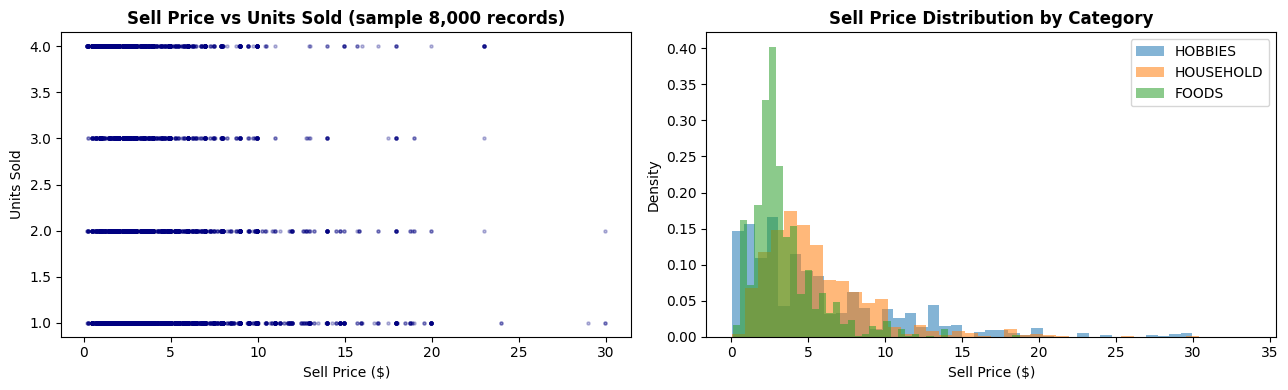

Pearson correlation (price vs sales): -0.2207
Interpretation: negative correlation means higher price → lower units sold


In [22]:
sample = df[df['sell_price'].notna() & (df['sales'] > 0)].sample(
    min(8000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(sample['sell_price'], sample['sales'],
                alpha=0.25, s=5, color='navy')
axes[0].set_title('Sell Price vs Units Sold (sample 8,000 records)', fontweight='bold')
axes[0].set_xlabel('Sell Price ($)'); axes[0].set_ylabel('Units Sold')

# Price distribution by category
for cat, grp in df[df['sell_price'].notna()].groupby('cat_id'):
    axes[1].hist(grp['sell_price'].values, bins=40, alpha=0.55, label=cat, density=True)
axes[1].set_title('Sell Price Distribution by Category', fontweight='bold')
axes[1].set_xlabel('Sell Price ($)'); axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout(); plt.show()

corr = sample['sell_price'].corr(sample['sales'])
print(f"Pearson correlation (price vs sales): {corr:.4f}")
print("Interpretation: negative correlation means higher price → lower units sold")

## PHASE 4 FEATURE ENGINEERING

#### Sort Data by id → date

In [23]:
df = df.sort_values(['id','date']).reset_index(drop=True)
print("Data sorted. Shape:", df.shape)
print(df[['id','date','sales','sell_price']].head(8).to_string(index=False))

Data sorted. Shape: (2744100, 22)
                           id       date  sales  sell_price
HOBBIES_1_001_CA_1_validation 2016-01-26    1.0        8.26
HOBBIES_1_001_CA_1_validation 2016-01-27    1.0        8.26
HOBBIES_1_001_CA_1_validation 2016-01-28    1.0        8.26
HOBBIES_1_001_CA_1_validation 2016-01-29    0.0        8.26
HOBBIES_1_001_CA_1_validation 2016-01-30    0.0        8.26
HOBBIES_1_001_CA_1_validation 2016-01-31    1.0        8.26
HOBBIES_1_001_CA_1_validation 2016-02-01    1.0        8.26
HOBBIES_1_001_CA_1_validation 2016-02-02    1.0        8.26


#### Lag Features

In [24]:
# Lag 7, 14, 28 days — always using shift() to prevent leakage
for lag in [7, 14, 28]:
    df[f'sales_lag_{lag}'] = (df.groupby('id')['sales']
                               .shift(lag)
                               .astype(np.float32))

print("Lag features created: sales_lag_7, sales_lag_14, sales_lag_28")
print()
sample_item = df[df['item_id'] == df['item_id'].unique()[0]].head(35)
print(sample_item[['date','sales','sales_lag_7','sales_lag_14','sales_lag_28']].to_string(index=False))

Lag features created: sales_lag_7, sales_lag_14, sales_lag_28

      date  sales  sales_lag_7  sales_lag_14  sales_lag_28
2016-01-26    1.0          NaN           NaN           NaN
2016-01-27    1.0          NaN           NaN           NaN
2016-01-28    1.0          NaN           NaN           NaN
2016-01-29    0.0          NaN           NaN           NaN
2016-01-30    0.0          NaN           NaN           NaN
2016-01-31    1.0          NaN           NaN           NaN
2016-02-01    1.0          NaN           NaN           NaN
2016-02-02    1.0          1.0           NaN           NaN
2016-02-03    1.0          1.0           NaN           NaN
2016-02-04    1.0          1.0           NaN           NaN
2016-02-05    0.0          0.0           NaN           NaN
2016-02-06    0.0          0.0           NaN           NaN
2016-02-07    0.0          1.0           NaN           NaN
2016-02-08    2.0          1.0           NaN           NaN
2016-02-09    2.0          1.0           1.0        

#### Rolling Statistics

In [25]:
# 7-day and 28-day rolling mean & std (shift(1) prevents same-day leakage)
for window in [7, 28]:
    df[f'rolling_mean_{window}'] = (
        df.groupby('id')['sales']
          .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
          .astype(np.float32))
    df[f'rolling_std_{window}'] = (
        df.groupby('id')['sales']
          .transform(lambda x: x.shift(1).rolling(window, min_periods=1).std())
          .fillna(0).astype(np.float32))

print("Rolling features created: rolling_mean_7/28, rolling_std_7/28")
sample_item = df[df['item_id'] == df['item_id'].unique()[5]].head(35)
print(sample_item[['date','sales','rolling_mean_7','rolling_std_7','rolling_mean_28']].to_string(index=False))

Rolling features created: rolling_mean_7/28, rolling_std_7/28
      date  sales  rolling_mean_7  rolling_std_7  rolling_mean_28
2016-01-26    0.0             NaN       0.000000              NaN
2016-01-27    1.0        0.000000       0.000000         0.000000
2016-01-28    0.0        0.500000       0.707107         0.500000
2016-01-29    3.0        0.333333       0.577350         0.333333
2016-01-30    0.0        1.000000       1.414214         1.000000
2016-01-31    0.0        0.800000       1.303841         0.800000
2016-02-01    0.0        0.666667       1.211060         0.666667
2016-02-02    1.0        0.571429       1.133893         0.571429
2016-02-03    3.0        0.714286       1.112697         0.625000
2016-02-04    0.0        1.000000       1.414214         0.888889
2016-02-05    0.0        1.000000       1.414214         0.800000
2016-02-06    1.0        0.571429       1.133893         0.727273
2016-02-07    0.0        0.714286       1.112697         0.750000
2016-02-08    

#### Price Elasticity Features

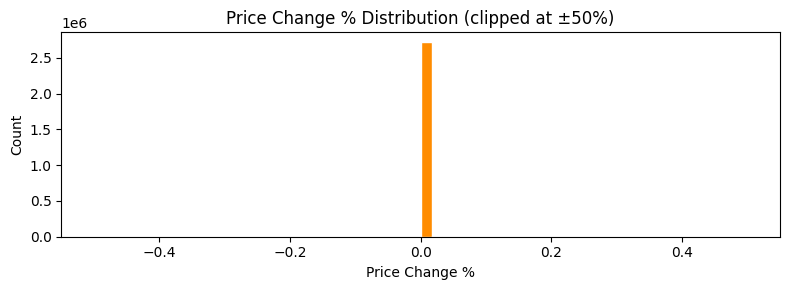

      date  sell_price  price_lag_7  price_change_pct
2016-02-02        8.26         8.26               0.0
2016-02-03        8.26         8.26               0.0
2016-02-04        8.26         8.26               0.0
2016-02-05        8.26         8.26               0.0
2016-02-06        8.26         8.26               0.0
2016-02-07        8.26         8.26               0.0
2016-02-08        8.26         8.26               0.0
2016-02-09        8.26         8.26               0.0


In [26]:
df['price_lag_7']      = (df.groupby('id')['sell_price'].shift(7).astype(np.float32))
df['price_change_pct'] = (
    ((df['sell_price'] - df['price_lag_7']) / (df['price_lag_7'] + 1e-5))
    .fillna(0).astype(np.float32))

# Distribution of price changes
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(df['price_change_pct'].clip(-0.5, 0.5).values, bins=60, color='darkorange', edgecolor='white')
ax.set_title('Price Change % Distribution (clipped at ±50%)')
ax.set_xlabel('Price Change %'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

print(df[['date','sell_price','price_lag_7','price_change_pct']].dropna().head(8).to_string(index=False))

#### Seasonal Features

In [27]:
df['date'] = pd.to_datetime(df['date'])
df['day_of_week']    = df['date'].dt.dayofweek.astype(np.int8)
df['day_of_month']   = df['date'].dt.day.astype(np.int8)
df['week_of_year']   = df['date'].dt.isocalendar().week.astype(np.int8)
df['quarter']        = df['date'].dt.quarter.astype(np.int8)
df['is_weekend']     = (df['day_of_week'] >= 5).astype(np.int8)
df['is_month_start'] = df['date'].dt.is_month_start.astype(np.int8)
df['is_month_end']   = df['date'].dt.is_month_end.astype(np.int8)

print("Seasonal features created.")
print(df[['date','day_of_week','week_of_year','quarter','is_weekend',
          'is_month_start','is_month_end']].head(8).to_string(index=False))

Seasonal features created.
      date  day_of_week  week_of_year  quarter  is_weekend  is_month_start  is_month_end
2016-01-26            1             4        1           0               0             0
2016-01-27            2             4        1           0               0             0
2016-01-28            3             4        1           0               0             0
2016-01-29            4             4        1           0               0             0
2016-01-30            5             4        1           1               0             0
2016-01-31            6             4        1           1               0             1
2016-02-01            0             5        1           0               1             0
2016-02-02            1             5        1           0               0             0


#### Event Features

In [28]:
df['has_event']    = (df['event_type_1'] != 'None').astype(np.int8)
df['is_sporting']  = (df['event_type_1'] == 'Sporting').astype(np.int8)
df['is_cultural']  = (df['event_type_1'] == 'Cultural').astype(np.int8)
df['is_national']  = (df['event_type_1'] == 'National').astype(np.int8)
df['is_religious'] = (df['event_type_1'] == 'Religious').astype(np.int8)

# SNAP: use each state's own SNAP flag for items sold in that state
df['snap_flag'] = np.int8(0)
df.loc[df['state_id'] == 'CA', 'snap_flag'] = df.loc[df['state_id'] == 'CA', 'snap_CA'].values
df.loc[df['state_id'] == 'TX', 'snap_flag'] = df.loc[df['state_id'] == 'TX', 'snap_TX'].values
df.loc[df['state_id'] == 'WI', 'snap_flag'] = df.loc[df['state_id'] == 'WI', 'snap_WI'].values

print("Event features created.")
print(df[['date','event_type_1','has_event','is_national','is_religious','snap_flag']].head(10).to_string(index=False))

print(f"\nSNAP days in window: {df['snap_flag'].sum():,}")
print(f"Event days in window: {df['has_event'].sum():,}")

Event features created.
      date event_type_1  has_event  is_national  is_religious  snap_flag
2016-01-26         None          0            0             0          0
2016-01-27         None          0            0             0          0
2016-01-28         None          0            0             0          0
2016-01-29         None          0            0             0          0
2016-01-30         None          0            0             0          0
2016-01-31         None          0            0             0          0
2016-02-01         None          0            0             0          1
2016-02-02         None          0            0             0          1
2016-02-03         None          0            0             0          1
2016-02-04         None          0            0             0          1

SNAP days in window: 914,700
Event days in window: 243,920


#### Encode Categorical Features

In [29]:
le = LabelEncoder()
for col in ['item_id','dept_id','cat_id','store_id','state_id']:
    df[col+'_enc'] = le.fit_transform(df[col].astype(str)).astype(np.int16)

print("Label encoding done.")
print(df[['item_id','item_id_enc','dept_id','dept_id_enc',
          'store_id','store_id_enc','state_id','state_id_enc']].head(6).to_string(index=False))
gc.collect()

Label encoding done.
      item_id  item_id_enc   dept_id  dept_id_enc store_id  store_id_enc state_id  state_id_enc
HOBBIES_1_001         1437 HOBBIES_1            3     CA_1             0       CA             0
HOBBIES_1_001         1437 HOBBIES_1            3     CA_1             0       CA             0
HOBBIES_1_001         1437 HOBBIES_1            3     CA_1             0       CA             0
HOBBIES_1_001         1437 HOBBIES_1            3     CA_1             0       CA             0
HOBBIES_1_001         1437 HOBBIES_1            3     CA_1             0       CA             0
HOBBIES_1_001         1437 HOBBIES_1            3     CA_1             0       CA             0


8968

#### Define Feature Set & Train/Test Split

In [30]:
FEATURE_COLS = [
    'item_id_enc', 'dept_id_enc', 'cat_id_enc', 'store_id_enc', 'state_id_enc',
    'sell_price', 'price_change_pct',
    'sales_lag_7', 'sales_lag_14', 'sales_lag_28',
    'rolling_mean_7', 'rolling_std_7', 'rolling_mean_28', 'rolling_std_28',
    'day_of_week', 'day_of_month', 'week_of_year', 'month', 'year', 'quarter',
    'is_weekend', 'is_month_start', 'is_month_end', 'wday',
    'has_event', 'is_sporting', 'is_cultural', 'is_national', 'is_religious',
    'snap_flag'
]
TARGET = 'sales'

# Drop rows with NaN lag features (first 28 days per item have incomplete lags)
model_df = df.dropna(subset=FEATURE_COLS + [TARGET]).copy()

# Time-based split: last 28 days = test
cutoff_date = model_df['date'].max() - pd.Timedelta(days=28)
train_df = model_df[model_df['date'] <= cutoff_date]
test_df  = model_df[model_df['date'] >  cutoff_date]

print(f"Features          : {len(FEATURE_COLS)}")
print(f"Model-ready rows  : {len(model_df):>10,}")
print(f"Train rows        : {len(train_df):>10,}  "
      f"({train_df['date'].min().date()} → {train_df['date'].max().date()})")
print(f"Test  rows        : {len(test_df):>10,}  "
      f"({test_df['date'].min().date()} → {test_df['date'].max().date()})")

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET]

Features          : 30
Model-ready rows  :  1,890,380
Train rows        :  1,036,660  (2016-02-23 → 2016-03-27)
Test  rows        :    853,720  (2016-03-28 → 2016-04-24)


## Phase 5 Forecasting Models


####  Metric Helper

In [31]:
results = []

def evaluate(name, y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.clip(np.asarray(y_pred, dtype=np.float64), 0, None)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mask = y_true > 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    print(f"  {name:<26} RMSE: {rmse:7.4f}  MAE: {mae:7.4f}  MAPE: {mape:6.2f}%")
    return dict(Model=name, RMSE=round(rmse,4), MAE=round(mae,4), MAPE=round(mape,2))

print("Metric helper ready.")

Metric helper ready.


#### Linear Regression

In [32]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

lr_model = LinearRegression(n_jobs=-1)
lr_model.fit(X_train_s, y_train)
lr_preds = np.clip(lr_model.predict(X_test_s), 0, None)

results.append(evaluate('Linear Regression', y_test, lr_preds))

  Linear Regression          RMSE:  0.9567  MAE:  0.7024  MAPE:  45.78%


####  Logistic Regression — Demand Classification (High vs Low)

In [33]:
# Binary target: 1 = above-median demand (High), 0 = Low
median_sales   = y_train.median()
y_train_bin    = (y_train > median_sales).astype(int)
y_test_bin     = (y_test  > median_sales).astype(int)

logr_model = LogisticRegression(max_iter=300, solver='lbfgs', n_jobs=-1)
logr_model.fit(X_train_s, y_train_bin)
logr_preds = logr_model.predict(X_test_s)

acc = accuracy_score(y_test_bin, logr_preds)
print(f"Logistic Regression — High/Low Demand Classification")
print(f"Median-sales threshold: {median_sales:.2f} units/day")
print(f"Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print()
print(classification_report(y_test_bin, logr_preds,
                             target_names=['Low Demand (≤ median)',
                                           'High Demand (> median)']))

Logistic Regression — High/Low Demand Classification
Median-sales threshold: 0.00 units/day
Accuracy : 0.7375  (73.75%)

                        precision    recall  f1-score   support

 Low Demand (≤ median)       0.74      0.83      0.78    480460
High Demand (> median)       0.74      0.61      0.67    373260

              accuracy                           0.74    853720
             macro avg       0.74      0.72      0.73    853720
          weighted avg       0.74      0.74      0.73    853720



#### K-Nearest Neighbors (KNN) Regressor

In [34]:
# Sample training set to keep RAM manageable
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_train_s), min(80_000, len(X_train_s)), replace=False)

knn_model = KNeighborsRegressor(n_neighbors=10, n_jobs=-1)
knn_model.fit(X_train_s[sample_idx], y_train.values[sample_idx])
knn_preds = knn_model.predict(X_test_s)

results.append(evaluate('KNN Regressor', y_test, knn_preds))

  KNN Regressor              RMSE:  1.0041  MAE:  0.7104  MAPE:  50.45%


 ####  Decision Tree Regressor

In [35]:
dt_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=50,
    random_state=42
)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

results.append(evaluate('Decision Tree', y_test, dt_preds))

  Decision Tree              RMSE:  0.9531  MAE:  0.6841  MAPE:  47.03%


####  Random Forest Regressor

In [36]:
rf_model = RandomForestRegressor(
    n_estimators=80,
    max_depth=12,
    min_samples_leaf=30,
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

results.append(evaluate('Random Forest', y_test, rf_preds))

  Random Forest              RMSE:  0.9485  MAE:  0.6831  MAPE:  46.82%


####  XGBoost

In [37]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
xgb_preds = np.clip(xgb_model.predict(X_test), 0, None)

results.append(evaluate('XGBoost', y_test, xgb_preds))

  XGBoost                    RMSE:  0.9461  MAE:  0.6830  MAPE:  46.44%


#### LightGBM

In [38]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=30,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)]
)
lgb_preds = np.clip(lgb_model.predict(X_test), 0, None)

results.append(evaluate('LightGBM', y_test, lgb_preds))

  LightGBM                   RMSE:  0.9470  MAE:  0.6823  MAPE:  46.61%


#### CatBoost

In [39]:
cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=0
)
cat_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test)
)
cat_preds = np.clip(cat_model.predict(X_test), 0, None)

results.append(evaluate('CatBoost', y_test, cat_preds))

  CatBoost                   RMSE:  0.9469  MAE:  0.6842  MAPE:  46.49%


#### LSTM — Aggregate Daily Sales Forecast

In [40]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    print(f"TensorFlow {tf.__version__}")
    LSTM_AVAILABLE = True
except ImportError:
    print("TensorFlow not installed — skipping LSTM.")
    LSTM_AVAILABLE = False
if LSTM_AVAILABLE:
    LOOKBACK = 28

    # Aggregate daily sales across all SKUs
    daily_agg = (df.groupby('date')['sales'].sum()
                   .reset_index().sort_values('date'))

    lstm_scaler = StandardScaler()
    values_s = lstm_scaler.fit_transform(daily_agg[['sales']].values)

    # Build (samples, LOOKBACK, 1) sequences
    X_lstm, y_lstm = [], []
    for i in range(LOOKBACK, len(values_s)):
        X_lstm.append(values_s[i - LOOKBACK:i, 0])
        y_lstm.append(values_s[i, 0])

    X_lstm = np.array(X_lstm).reshape(-1, LOOKBACK, 1)
    y_lstm = np.array(y_lstm)

    split = int(len(X_lstm) * 0.75)
    X_lt, X_lv = X_lstm[:split], X_lstm[split:]
    y_lt, y_lv = y_lstm[:split], y_lstm[split:]
    print(f"LSTM train: {X_lt.shape}  val: {X_lv.shape}")
if LSTM_AVAILABLE:
    lstm_model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    lstm_model.compile(optimizer='adam', loss='mse')
    lstm_model.summary()

    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = lstm_model.fit(
        X_lt, y_lt,
        epochs=40,
        batch_size=16,
        validation_data=(X_lv, y_lv),
        callbacks=[es],
        verbose=1
    )
if LSTM_AVAILABLE:
    # Training loss plot
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(history.history['loss'],     label='Train Loss', linewidth=1.5)
    ax.plot(history.history['val_loss'], label='Val Loss',   linewidth=1.5)
    ax.set_title('LSTM Training History'); ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
    ax.legend(); plt.tight_layout(); plt.show()

    # Evaluate
    lstm_pred_s  = lstm_model.predict(X_lv)
    lstm_pred    = lstm_scaler.inverse_transform(lstm_pred_s).flatten()
    lstm_actual  = lstm_scaler.inverse_transform(y_lv.reshape(-1,1)).flatten()
    lstm_rmse    = np.sqrt(mean_squared_error(lstm_actual, lstm_pred))
    lstm_mae     = mean_absolute_error(lstm_actual, lstm_pred)
    print(f"  LSTM (Aggregate Daily)         RMSE: {lstm_rmse:7.2f}  MAE: {lstm_mae:7.2f}")

    # Actual vs predicted plot
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(lstm_actual, label='Actual',    color='steelblue', linewidth=1.5)
    ax.plot(lstm_pred,   label='Predicted', color='tomato',    linewidth=1.5, linestyle='--')
    ax.set_title('LSTM — Actual vs Predicted Aggregate Daily Sales')
    ax.set_xlabel('Days in Val Set'); ax.set_ylabel('Total Units Sold')
    ax.legend(); plt.tight_layout(); plt.show()

TensorFlow not installed — skipping LSTM.


####  Model Comparison

  MODEL COMPARISON  (lower RMSE / MAE / MAPE = better)
            Model   RMSE    MAE  MAPE
          XGBoost 0.9461 0.6830 46.44
         CatBoost 0.9469 0.6842 46.49
         LightGBM 0.9470 0.6823 46.61
    Random Forest 0.9485 0.6831 46.82
    Decision Tree 0.9531 0.6841 47.03
Linear Regression 0.9567 0.7024 45.78
    KNN Regressor 1.0041 0.7104 50.45

  Best model: XGBoost
  RMSE=0.9461  MAE=0.683  MAPE=46.44%


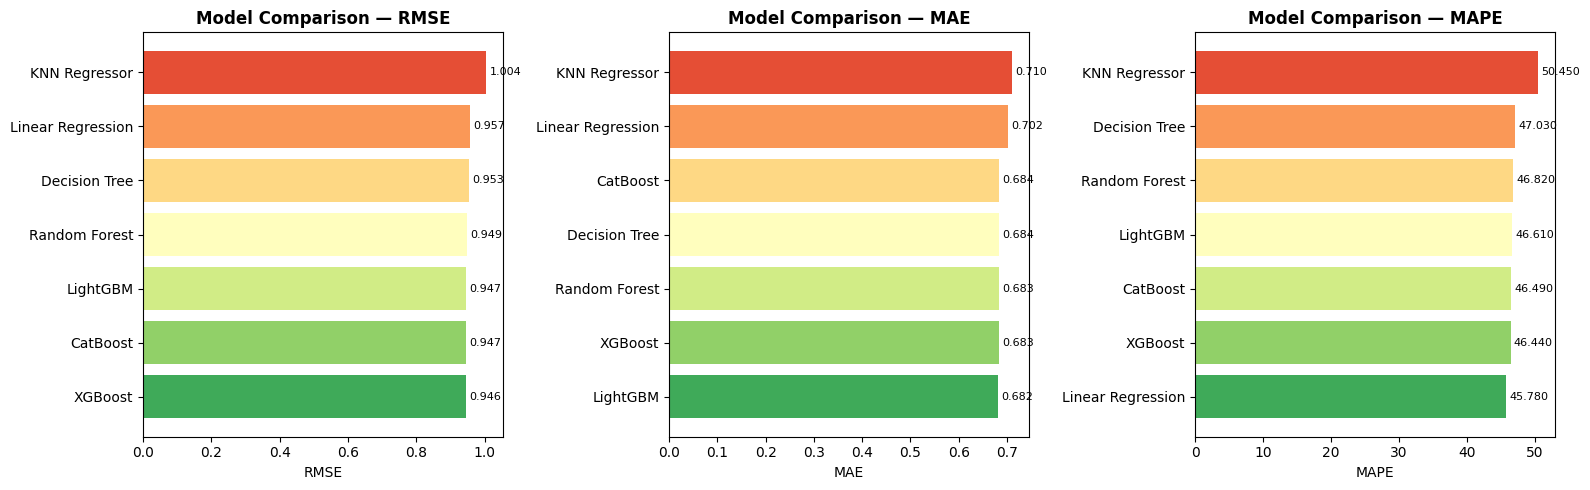

In [41]:
results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
print("=" * 62)
print("  MODEL COMPARISON  (lower RMSE / MAE / MAPE = better)")
print("=" * 62)
print(results_df.to_string(index=False))
print()
best = results_df.iloc[0]
print(f"  Best model: {best['Model']}")
print(f"  RMSE={best['RMSE']}  MAE={best['MAE']}  MAPE={best['MAPE']}%")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['RMSE', 'MAE', 'MAPE']
palette = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(results_df)))

for ax, metric in zip(axes, metrics):
    sdf = results_df.sort_values(metric)
    bars = ax.barh(sdf['Model'], sdf[metric], color=palette)
    ax.set_title(f'Model Comparison — {metric}', fontweight='bold')
    ax.set_xlabel(metric)
    for bar, val in zip(bars, sdf[metric]):
        ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout(); plt.show()
# Actual vs Predicted for best model
best_preds_map = {
    'Linear Regression': lr_preds,
    'KNN Regressor':     knn_preds,
    'Decision Tree':     dt_preds,
    'Random Forest':     rf_preds,
    'XGBoost':           xgb_preds,
    'LightGBM':          lgb_preds,
    'CatBoost':          cat_preds,
}
best_name = results_df.iloc[0]['Model']
best_pred = best_preds_map.get(best_name, xgb_preds)

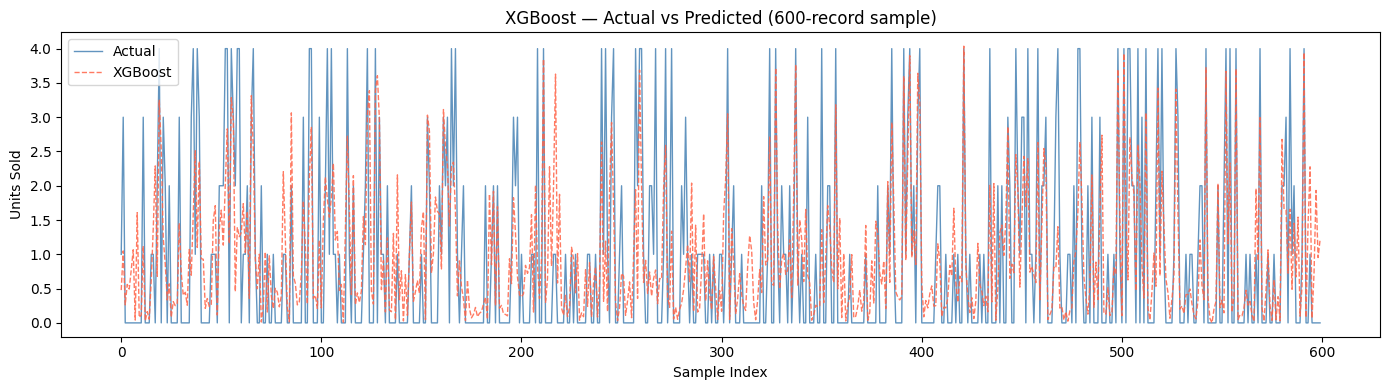

In [42]:
# Sample 600 test points for readability
rng = np.random.default_rng(0)
idx = rng.choice(len(y_test), min(600, len(y_test)), replace=False)
idx_sorted = np.sort(idx)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_test.values[idx_sorted],  label='Actual',    color='steelblue', linewidth=1, alpha=0.85)
ax.plot(best_pred[idx_sorted],      label=f'{best_name}', color='tomato', linewidth=1,
        linestyle='--', alpha=0.85)
ax.set_title(f'{best_name} — Actual vs Predicted (600-record sample)')
ax.set_xlabel('Sample Index'); ax.set_ylabel('Units Sold'); ax.legend()
plt.tight_layout(); plt.show()

## Phase 6 — Inventory Optimization

####  Safety Stock Estimation

In [43]:

# Parameters
Z_SCORE    = 1.65    # 95% service level
LEAD_TIME  = 7       # days from order to receipt

item_stats = (train_df.groupby('item_id')['sales']
                      .agg(mean_daily='mean', std_daily='std')
                      .reset_index())
item_stats['std_daily'] = item_stats['std_daily'].fillna(0)

# Safety Stock = Z × σ × √(lead_time)
item_stats['safety_stock'] = (Z_SCORE * item_stats['std_daily']
                                       * np.sqrt(LEAD_TIME)).round(2)

print("Safety Stock Parameters:")
print(f"  Z-score     : {Z_SCORE}  (95% service level)")
print(f"  Lead time   : {LEAD_TIME} days")
print()
print("Top 10 items by safety stock:")
print(item_stats.sort_values('safety_stock', ascending=False).head(10).to_string(index=False))

Safety Stock Parameters:
  Z-score     : 1.65  (95% service level)
  Lead time   : 7 days

Top 10 items by safety stock:
        item_id  mean_daily  std_daily  safety_stock
    FOODS_3_120    1.958824   1.992185          8.70
    FOODS_2_360    2.502941   1.874371          8.18
  HOBBIES_1_234    1.773529   1.868511          8.16
    FOODS_3_752    1.955882   1.858043          8.11
    FOODS_2_128    2.082353   1.852762          8.09
    FOODS_3_147    1.641176   1.845207          8.06
    FOODS_3_711    2.029412   1.846392          8.06
HOUSEHOLD_1_191    1.641176   1.843608          8.05
    FOODS_2_021    1.805882   1.841178          8.04
    FOODS_3_077    1.708824   1.832333          8.00


####  Reorder Point & Order Quantity

  INVENTORY RECOMMENDATIONS  (Top 15 by reorder point)
        item_id  mean_daily  std_daily  safety_stock  reorder_point  recommended_order_qty
    FOODS_3_288    3.726470   0.952503          4.16      30.250000                   52.0
    FOODS_3_282    3.735294   0.918792          4.01      30.160000                   52.0
    FOODS_3_099    3.752941   0.840085          3.67      29.940001                   53.0
    FOODS_3_587    3.397059   1.411496          6.16      29.940001                   48.0
    FOODS_3_682    3.461765   1.267361          5.53      29.760000                   48.0
    FOODS_3_681    3.729412   0.829233          3.62      29.730000                   52.0
HOUSEHOLD_1_334    3.708823   0.859055          3.75      29.709999                   52.0
    FOODS_1_085    3.700000   0.867982          3.79      29.690001                   52.0
HOUSEHOLD_1_110    3.594118   1.027625          4.49      29.650000                   50.0
    FOODS_3_739    3.758824   0.764

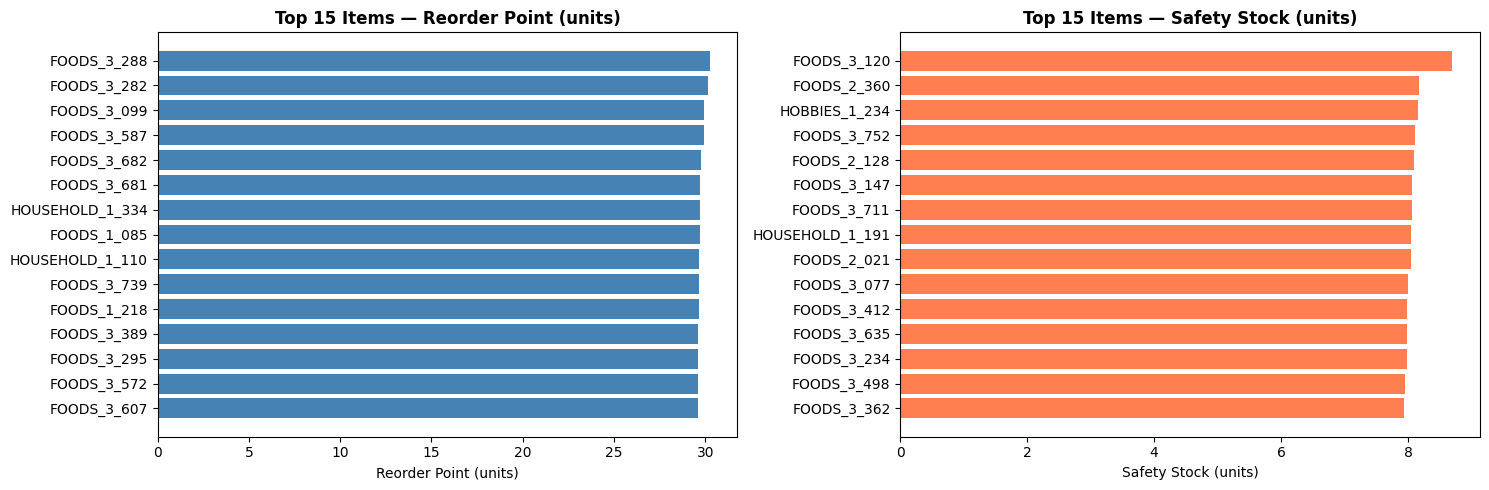


Inventory formulas:
  Safety Stock     = Z × σ(daily demand) × √(Lead Time)
  Reorder Point    = (Avg daily demand × Lead Time) + Safety Stock
  Order Quantity   = Avg daily demand × Order Cycle


In [44]:

ORDER_CYCLE = 14  # days between replenishments

# Reorder Point = (avg daily demand × lead time) + safety stock
item_stats['reorder_point']       = (item_stats['mean_daily'] * LEAD_TIME
                                     + item_stats['safety_stock']).round(2)
item_stats['recommended_order_qty'] = (item_stats['mean_daily'] * ORDER_CYCLE).round(0)

print("=" * 72)
print("  INVENTORY RECOMMENDATIONS  (Top 15 by reorder point)")
print("=" * 72)
display_cols = ['item_id','mean_daily','std_daily','safety_stock',
                'reorder_point','recommended_order_qty']
print(item_stats.sort_values('reorder_point', ascending=False)
               [display_cols].head(15).to_string(index=False))

# Save for Streamlit dashboard
item_stats.to_csv('inventory_recommendations.csv', index=False)
print("\nSaved → inventory_recommendations.csv")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top15 = item_stats.sort_values('reorder_point', ascending=False).head(15)

axes[0].barh(top15['item_id'], top15['reorder_point'], color='steelblue')
axes[0].set_title('Top 15 Items — Reorder Point (units)', fontweight='bold')
axes[0].set_xlabel('Reorder Point (units)'); axes[0].invert_yaxis()

top15_ss = item_stats.sort_values('safety_stock', ascending=False).head(15)
axes[1].barh(top15_ss['item_id'], top15_ss['safety_stock'], color='coral')
axes[1].set_title('Top 15 Items — Safety Stock (units)', fontweight='bold')
axes[1].set_xlabel('Safety Stock (units)'); axes[1].invert_yaxis()

plt.tight_layout(); plt.show()

print("\nInventory formulas:")
print("  Safety Stock     = Z × σ(daily demand) × √(Lead Time)")
print("  Reorder Point    = (Avg daily demand × Lead Time) + Safety Stock")
print("  Order Quantity   = Avg daily demand × Order Cycle")


####  Demand Anomaly Detection

Z-score threshold : 2.5
Anomaly days      : 0 / 90 total days

Empty DataFrame
Columns: [date, sales, z_score]
Index: []


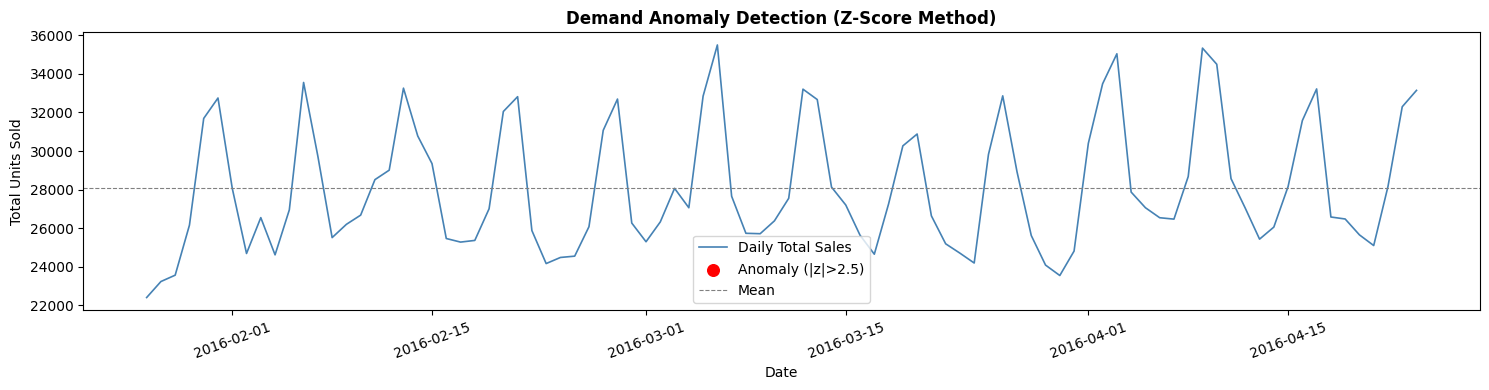

In [45]:
daily_agg = df.groupby('date')['sales'].sum().reset_index()

daily_agg['z_score'] = ((daily_agg['sales'] - daily_agg['sales'].mean())
                         / daily_agg['sales'].std())
Z_THRESH = 2.5
daily_agg['anomaly'] = (daily_agg['z_score'].abs() > Z_THRESH).astype(int)

anomalies = daily_agg[daily_agg['anomaly'] == 1]
print(f"Z-score threshold : {Z_THRESH}")
print(f"Anomaly days      : {len(anomalies)} / {len(daily_agg)} total days")
print()
print(anomalies[['date','sales','z_score']].sort_values('z_score', key=abs, ascending=False).to_string(index=False))

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(daily_agg['date'], daily_agg['sales'],
        color='steelblue', linewidth=1.2, label='Daily Total Sales')
ax.scatter(anomalies['date'], anomalies['sales'],
           color='red', s=70, zorder=5, label=f'Anomaly (|z|>{Z_THRESH})')
ax.axhline(daily_agg['sales'].mean(), color='grey', linestyle='--', linewidth=0.8, label='Mean')
ax.set_title('Demand Anomaly Detection (Z-Score Method)', fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Total Units Sold')
ax.legend(); ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

## PHASE 7

####  Built-in Feature Importance (XGBoost & LightGBM)

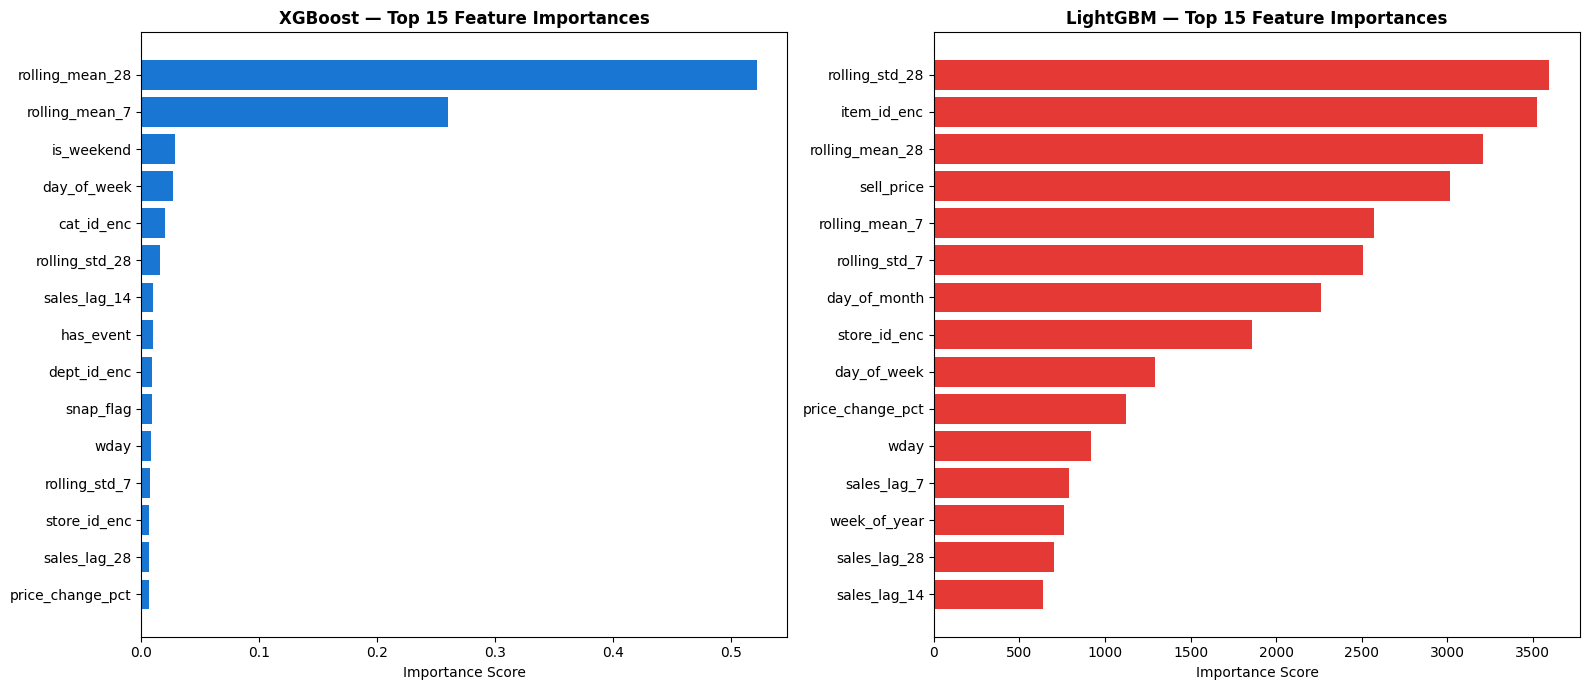

Top 10 XGBoost Features:
rolling_mean_28    0.5216
rolling_mean_7     0.2598
is_weekend         0.0284
day_of_week        0.0267
cat_id_enc         0.0197
rolling_std_28     0.0155
sales_lag_14       0.0102
has_event          0.0102
dept_id_enc        0.0093
snap_flag          0.0089


In [46]:
xgb_fi = pd.Series(xgb_model.feature_importances_,
                   index=FEATURE_COLS).sort_values(ascending=False)
lgb_fi = pd.Series(lgb_model.feature_importances_,
                   index=FEATURE_COLS).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_n = 15
ax = axes[0]
xgb_top = xgb_fi.head(top_n)
ax.barh(xgb_top.index[::-1], xgb_top.values[::-1], color='#1976D2')
ax.set_title(f'XGBoost — Top {top_n} Feature Importances', fontweight='bold')
ax.set_xlabel('Importance Score')

ax = axes[1]
lgb_top = lgb_fi.head(top_n)
ax.barh(lgb_top.index[::-1], lgb_top.values[::-1], color='#E53935')
ax.set_title(f'LightGBM — Top {top_n} Feature Importances', fontweight='bold')
ax.set_xlabel('Importance Score')

plt.tight_layout(); plt.show()

print("Top 10 XGBoost Features:")
print(xgb_fi.head(10).round(4).to_string())

####  SHAP Values (XGBoost)

In [47]:
try:
    import shap
    SHAP_AVAILABLE = True
    print(f"shap version: {shap.__version__}")
except ImportError:
    print("shap not installed — run:  pip install shap")
    SHAP_AVAILABLE = False

shap not installed — run:  pip install shap


In [48]:
if SHAP_AVAILABLE:
    # Use a small sample to keep computation fast
    shap_sample = X_test.sample(min(1000, len(X_test)), random_state=42)

    explainer   = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(shap_sample)

    # SHAP bar summary
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, shap_sample, plot_type='bar',
                      show=False, color='#1976D2')
    plt.title('SHAP Feature Importance (XGBoost) — Mean |SHAP|', fontweight='bold')
    plt.tight_layout(); plt.show()

    # SHAP beeswarm
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, shap_sample, show=False)
    plt.title('SHAP Beeswarm Plot — Feature Impact Direction', fontweight='bold')
    plt.tight_layout(); plt.show()

## Phase 8 — Save Models & Artifacts

In [49]:
os.makedirs('models', exist_ok=True)
os.makedirs('artifacts', exist_ok=True)

# Save ML models
joblib.dump(xgb_model,  'models/xgb_model.pkl')
joblib.dump(lgb_model,  'models/lgb_model.pkl')
joblib.dump(cat_model,  'models/cat_model.pkl')
joblib.dump(rf_model,   'models/rf_model.pkl')
joblib.dump(dt_model,   'models/dt_model.pkl')
joblib.dump(lr_model,   'models/lr_model.pkl')
joblib.dump(scaler,     'models/scaler.pkl')

# Save LSTM (if trained)
if LSTM_AVAILABLE:
    lstm_model.save('models/lstm_model.keras')
    joblib.dump(lstm_scaler, 'models/lstm_scaler.pkl')

# Save results & feature list
results_df.to_csv('artifacts/model_results.csv', index=False)
pd.Series(FEATURE_COLS).to_csv('artifacts/feature_cols.csv', index=False, header=False)

print("Models saved to  models/")
print("Artifacts saved to artifacts/")
for f in sorted(os.listdir('models')):
    size = os.path.getsize(f'models/{f}')
    print(f"  models/{f:<30} {size/1024:>8.1f} KB")

Models saved to  models/
Artifacts saved to artifacts/
  models/cat_model.pkl                    8072.1 KB
  models/dt_model.pkl                       89.5 KB
  models/lgb_model.pkl                    2845.7 KB
  models/lr_model.pkl                        1.0 KB
  models/rf_model.pkl                    17124.8 KB
  models/scaler.pkl                          2.0 KB
  models/xgb_model.pkl                    2346.9 KB


## PROJECT SUMMARY


In [50]:
print("=" * 65)
print("  ENTERPRISE RETAIL INTELLIGENCE PLATFORM — SUMMARY")
print("=" * 65)
print(f"  Dataset      : M5 Forecasting — Walmart Sales")
print(f"  Products     : 30,490 SKUs × 10 stores")
print(f"  Date window  : 2016-01-26 → 2016-04-24 (90 days)")
print(f"  Train rows   : {len(train_df):>10,}")
print(f"  Test  rows   : {len(test_df):>10,}")
print(f"  Features     : {len(FEATURE_COLS)}")
print(f"  Models       : 7 ML + 1 LSTM (+ 1 Logistic Classifier)")
print()
print("  Model Leaderboard (sorted by RMSE):")
print("  " + "-"*55)
for _, row in results_df.iterrows():
    flag = " ← BEST" if row['Model'] == results_df.iloc[0]['Model'] else ""
    print(f"  {row['Model']:<26} RMSE={row['RMSE']:.4f}  MAPE={row['MAPE']:.2f}%{flag}")
print()
print(f"  Safety stock computed   : Yes (Z=1.65, 95% service level)")
print(f"  Anomaly days detected   : {len(anomalies)}")
print(f"  Inventory file saved    : inventory_recommendations.csv")
print(f"  Models folder           : models/")
print("=" * 65)

  ENTERPRISE RETAIL INTELLIGENCE PLATFORM — SUMMARY
  Dataset      : M5 Forecasting — Walmart Sales
  Products     : 30,490 SKUs × 10 stores
  Date window  : 2016-01-26 → 2016-04-24 (90 days)
  Train rows   :  1,036,660
  Test  rows   :    853,720
  Features     : 30
  Models       : 7 ML + 1 LSTM (+ 1 Logistic Classifier)

  Model Leaderboard (sorted by RMSE):
  -------------------------------------------------------
  XGBoost                    RMSE=0.9461  MAPE=46.44% ← BEST
  CatBoost                   RMSE=0.9469  MAPE=46.49%
  LightGBM                   RMSE=0.9470  MAPE=46.61%
  Random Forest              RMSE=0.9485  MAPE=46.82%
  Decision Tree              RMSE=0.9531  MAPE=47.03%
  Linear Regression          RMSE=0.9567  MAPE=45.78%
  KNN Regressor              RMSE=1.0041  MAPE=50.45%

  Safety stock computed   : Yes (Z=1.65, 95% service level)
  Anomaly days detected   : 0
  Inventory file saved    : inventory_recommendations.csv
  Models folder           : models/
